In [1]:
import sys
sys.path.append('/exp/icarus/app/users/zihaolin/REWEIGHTworkdir/')
from BDTReweight.nuisance_flat_tree import NuisanceFlatTree
from BDTReweight.analysis import transform_momentum_to_reaction_frame, draw_source_target_distributions_and_ratio, create_dataframe_from_nuisance
from BDTReweight.reweighter import Reweighter
from BDTReweight.utilities import particle_mass_lookup, particle_variable_to_latex, diff_xsec_latex_wrt_variable, load_flux_hist, hist_ratio_reweight
from BDTReweight.json_reweighter import JSONReweighter, export_reweighter_json

import awkward as ak
import matplotlib.pyplot as plt
import uproot
import pandas as pd
import numpy as np

import gc

## Train pp out-going state

In [2]:
# presets
target_vars = [
    'muon_Px', 'muon_Py', 'muon_Pz',
    'nucleon1_out_Px', 'nucleon1_out_Py','nucleon1_out_Pz',
    'nucleon2_out_Px','nucleon2_out_Py','nucleon2_out_Pz', 
    'weight_pp', 'neutrino_E', 'Q_E', 'Q_P'
]


source_vars = [ 
    'leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'init_neutrino_E', 'q0', 'q3'
]



exclusive_size_pp = 800000
# exclusive_size_pp = 80000


In [3]:
# prepare Valencia exclusive 2p2h pp state dataframe
 
with uproot.open(
        # # T2K sample:
        # '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/T2Kflux/KinematicVariables_Enu_T2K_Exclusive.root'
        # # ICARUS BNB sample:
        # '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/ICARUS_BNBflux/KinematicVariables_events_numu_C12_bnb_icarus_ReDelta_0_Exclusive.root'
        # ICARUS NuMI sample:
        '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/ICARUS_NuMIflux/KinematicVariables_events_numu_C12_numi_icarus_ReDelta_0_Exclusive.root'
    ) as f:
    df_target = f['T'].arrays(library='pd',entry_start=0, entry_stop=exclusive_size_pp)[target_vars]


df_target.columns = [
    'leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'weight', 'init_neutrino_E', 'q0', 'q3'
]


df_target = df_target.loc[df_target['weight']>=0]

for col in df_target.columns:
    if col != 'weight':
        df_target[col] = df_target[col]/1000 # MeV to GeV

df_target['Q2']= - df_target['q0']**2 + df_target['q3']**2


df_target = transform_momentum_to_reaction_frame(df_target, 
    selector_lepton='leading_muon',
    particle_names=['leading_proton','subleading_proton'])



In [4]:
# prepare GENIEv3 AR23 SuSAv2 2p2h pp state dataframe

tree_genie = NuisanceFlatTree(
    [f'/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/GENIEv3_AR23_ICARUS_NuMI_FHC_numu_C12_CCMEC_{genie_seed}_NUISFLAT.root' for genie_seed in range(500,510)]
    # [f'/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/GENIEv3_AR23_ICARUS_NuMI_FHC_numu_C12_CCMEC_{genie_seed}_NUISFLAT.root' for genie_seed in range(500,501)]
)


# drop Enu > 20 GeV events for now
mask_2p2h = (tree_genie._flattree_vars['Enu_true'] <= 20.0) & (tree_genie._flattree_vars['Mode'] == 2) & (tree_genie._flattree_vars['nvertp'] == 6)
# entries_2p2h = np.arange(0, len(mask_2p2h), 1)[mask_2p2h]
tree_genie.update_tree_with_mask(mask_2p2h)

vertp_pdg = tree_genie._flattree_vars['pdg_vert'][:,3:5]
vertp_E = tree_genie._flattree_vars['E_vert'][:,3:5]
vertp_px = tree_genie._flattree_vars['px_vert'][:,3:5]
vertp_py = tree_genie._flattree_vars['py_vert'][:,3:5]
vertp_pz = tree_genie._flattree_vars['pz_vert'][:,3:5]
Enu_true = tree_genie._flattree_vars['Enu_true']
q0 = tree_genie._flattree_vars['q0']
q3 = tree_genie._flattree_vars['q3']
Q2 = tree_genie._flattree_vars['Q2']


vertp_mass = ak.where(vertp_pdg == 2212, particle_mass_lookup('proton'),
    ak.where(vertp_pdg == 2112, particle_mass_lookup('neutron'), -999.0)
)
vertp_KE = vertp_E - vertp_mass
order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

mask = (primary_pdg == 2212) & (spectator_pdg == 2212) # pp final states
# mask = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212)) # pn final states



# prepare SuSAv2 2p2h dataframe
df_source = pd.DataFrame() 
df_source['init_neutrino_E'] = Enu_true[mask]
df_source['q0'] = q0[mask]
df_source['q3'] = q3[mask]
df_source['Q2'] = Q2[mask]


df_source['leading_muon_px'] = tree_genie._flattree_vars['px_vert'][:,5][mask]
df_source['leading_muon_py'] = tree_genie._flattree_vars['py_vert'][:,5][mask]
df_source['leading_muon_pz'] = tree_genie._flattree_vars['pz_vert'][:,5][mask]
 
# pp channel proton kinematics:
leading_i = ak.argmax(vertp_KE, axis=1, keepdims=True)
subleading_i = ak.argmin(vertp_KE, axis=1, keepdims=True)

df_source['leading_proton_px'] = vertp_px[leading_i][mask]
df_source['leading_proton_py'] = vertp_py[leading_i][mask]
df_source['leading_proton_pz'] = vertp_pz[leading_i][mask]
df_source['subleading_proton_px'] = vertp_px[subleading_i][mask]
df_source['subleading_proton_py'] = vertp_py[subleading_i][mask]
df_source['subleading_proton_pz'] = vertp_pz[subleading_i][mask]

df_source = transform_momentum_to_reaction_frame(df_source, 
    selector_lepton='leading_muon',
    particle_names=['leading_proton','subleading_proton'])


In [5]:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(
    df_source[reweight_variables], df_target[reweight_variables],
    original_weight=np.ones(len(df_source)), # unweighted 
    target_weight=df_target['weight'],
)


Reweighter(gb_args={'subsample': 1.0}, learning_rate=0.1, max_depth=4,
           min_samples_leaf=20, n_estimators=200)

In [6]:
# predict weights
df_source['weight'] = reweighter.predict_weights(df_source[reweight_variables])
# df_source['weight'] = df_source['weight'] * np.ones(len(df_source)) / np.sum(df_source['weight'])

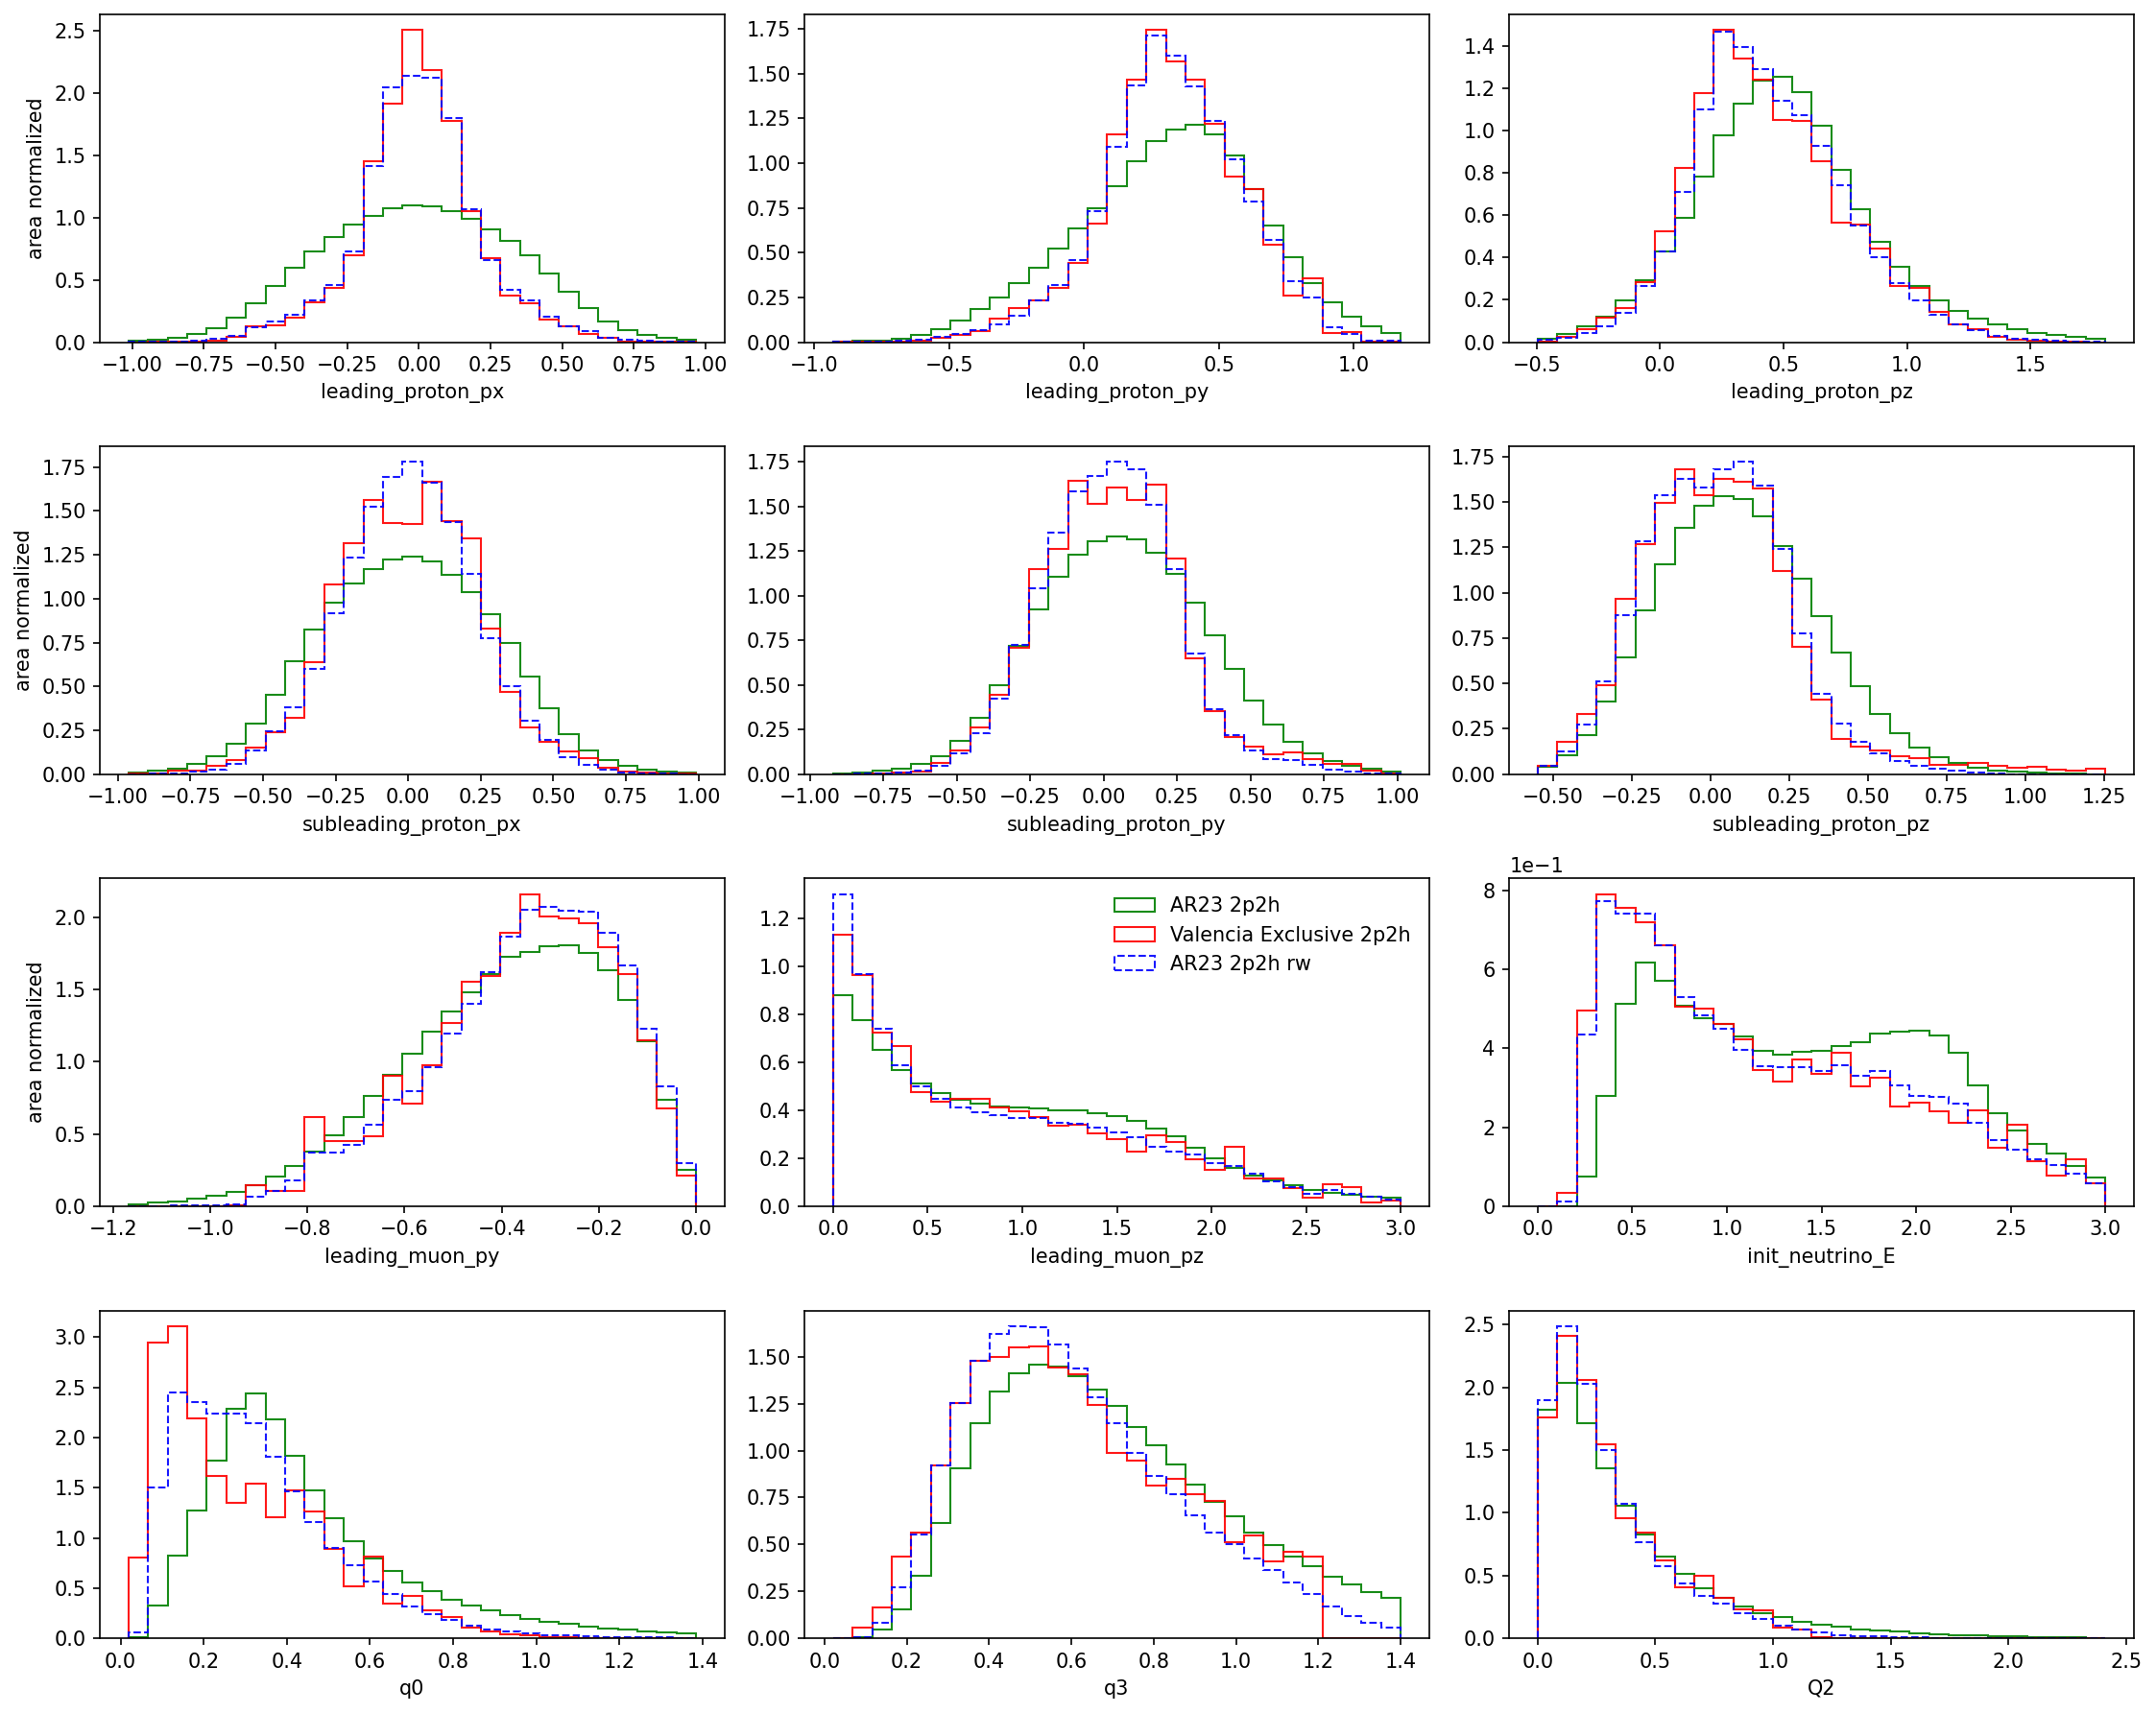

In [7]:
# plot histograms
plot_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E', 'q0', 'q3', 'Q2'
]

fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
for i, ax in enumerate(axs.flat):
    # if i == 8:
    #     continue;
    var = plot_variables[i]
    if i in [7, 8]:
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h',density=True)
    ax.hist(df_source[var], weights=df_source['weight'],     color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--',density=True)
    ax.set_xlabel(var)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    if i == 7:
        ax.legend(frameon=False)
    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
plt.tight_layout()
plt.show()

    
    

In [8]:
# save reweighter to json
export_reweighter_json(reweighter,
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pp_bdtreweighter_trainWithEnu.json'

)

In [9]:
# save dataframes to csv for future use
df_source.to_csv(
    # '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_2p2h_pp_states.csv',
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_ICARUS_NuMI_2p2h_pp_states.csv',

    index=False
)

df_target.to_csv(
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_ICARUS_NuMI_2p2h_pp_states.csv',
    index=False
)



In [10]:
print(len(df_source),len(df_target))

797757 774766


## Train pn out-going states

In [11]:
# presets
target_vars = [
    'muon_Px', 'muon_Py', 'muon_Pz',
    'nucleon1_out_Px', 'nucleon1_out_Py','nucleon1_out_Pz',
    'nucleon2_out_Px','nucleon2_out_Py','nucleon2_out_Pz', 
    'weight_pn','weight_np', 'neutrino_E', 'Q_E', 'Q_P'
]


source_vars = [
    'leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'init_neutrino_E', 'q0', 'q3', 'Q2'
]


exclusive_size_pn = 500000
# exclusive_size_pn = 50000


In [12]:
# prepare Valencia exclusive 2p2h pn state dataframe
 
with uproot.open(
        # # T2K sample:
        # '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/T2Kflux/KinematicVariables_Enu_T2K_Exclusive.root'
        # # ICARUS BNB sample:
        # '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/ICARUS_BNBflux/KinematicVariables_events_numu_C12_bnb_icarus_ReDelta_0_Exclusive.root'
        # ICARUS NuMI sample:
        '/exp/icarus/data/users/zihaolin/MC_outputs/Valencia2p2hsamples/ICARUS_NuMIflux/KinematicVariables_events_numu_C12_numi_icarus_ReDelta_0_Exclusive.root'
    ) as f:
    df_target = f['T'].arrays(library='pd',entry_start=0, entry_stop=exclusive_size_pn)[target_vars]

df_target.columns = [
    'leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'weight_pn', 'weight_np', 'init_neutrino_E', 'q0', 'q3'
]
df_target['weight'] = df_target['weight_pn'] + df_target['weight_np']

df_target = df_target.loc[df_target['weight']>=0]

for col in df_target.columns:
    if col != 'weight':
        df_target[col] = df_target[col]/1000 # MeV to GeV

df_target['Q2']= - df_target['q0']**2 + df_target['q3']**2


df_target = transform_momentum_to_reaction_frame(df_target, 
    selector_lepton='leading_muon',
    particle_names=['leading_proton','leading_neutron'])



In [13]:
# prepare GENIEv3 AR23 SuSAv2 2p2h pn state dataframe

tree_genie = NuisanceFlatTree(
    [f'/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/GENIEv3_AR23_ICARUS_NuMI_FHC_numu_C12_CCMEC_{genie_seed}_NUISFLAT.root' for genie_seed in range(500,520)]
    # [f'/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/GENIEv3_AR23_ICARUS_NuMI_FHC_numu_C12_CCMEC_{genie_seed}_NUISFLAT.root' for genie_seed in range(500,502)]
)


# drop Enu > 20 GeV events for now
mask_2p2h = (tree_genie._flattree_vars['Enu_true'] <= 20.0) & (tree_genie._flattree_vars['Mode'] == 2) & (tree_genie._flattree_vars['nvertp'] == 6)
# entries_2p2h = np.arange(0, len(mask_2p2h), 1)[mask_2p2h]
tree_genie.update_tree_with_mask(mask_2p2h)

vertp_pdg = tree_genie._flattree_vars['pdg_vert'][:,3:5]
vertp_E = tree_genie._flattree_vars['E_vert'][:,3:5]
vertp_px = tree_genie._flattree_vars['px_vert'][:,3:5]
vertp_py = tree_genie._flattree_vars['py_vert'][:,3:5]
vertp_pz = tree_genie._flattree_vars['pz_vert'][:,3:5]
Enu_true = tree_genie._flattree_vars['Enu_true']
q0 = tree_genie._flattree_vars['q0']
q3 = tree_genie._flattree_vars['q3']
Q2 = tree_genie._flattree_vars['Q2']


vertp_mass = ak.where(vertp_pdg == 2212, particle_mass_lookup('proton'),
    ak.where(vertp_pdg == 2112, particle_mass_lookup('neutron'), -999.0)
)
vertp_KE = vertp_E - vertp_mass
order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

# mask = (primary_pdg == 2212) & (spectator_pdg == 2212) # pp final states
mask = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212)) # pn final states



# prepare SuSAv2 2p2h dataframe
df_source = pd.DataFrame() 
df_source['init_neutrino_E'] = Enu_true[mask]
df_source['q0'] = q0[mask]
df_source['q3'] = q3[mask]
df_source['Q2'] = Q2[mask]


df_source['leading_muon_px'] = tree_genie._flattree_vars['px_vert'][:,5][mask]
df_source['leading_muon_py'] = tree_genie._flattree_vars['py_vert'][:,5][mask]
df_source['leading_muon_pz'] = tree_genie._flattree_vars['pz_vert'][:,5][mask]
 
# pn channel proton, neutron kinematics:
df_source['leading_proton_px'] = ak.firsts(vertp_px[vertp_pdg == 2212])[mask]
df_source['leading_proton_py'] = ak.firsts(vertp_py[vertp_pdg == 2212])[mask]
df_source['leading_proton_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2212])[mask]
df_source['leading_neutron_px'] = ak.firsts(vertp_px[vertp_pdg == 2112])[mask]
df_source['leading_neutron_py'] = ak.firsts(vertp_py[vertp_pdg == 2112])[mask]
df_source['leading_neutron_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2112])[mask]
df_source = transform_momentum_to_reaction_frame(df_source,
    selector_lepton='leading_muon', particle_names=['leading_proton', 'leading_neutron'])


df_source = transform_momentum_to_reaction_frame(df_source, 
    selector_lepton='leading_muon',
    particle_names=['leading_proton','leading_neutron'])

# garbage collection
del tree_genie
gc.collect()
print(len(df_source),len(df_target))


405557 435247


In [14]:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(
    df_source[reweight_variables], df_target[reweight_variables],
    original_weight=np.ones(len(df_source)), # unweighted 
    target_weight=df_target['weight'],
)


Reweighter(gb_args={'subsample': 1.0}, learning_rate=0.1, max_depth=4,
           min_samples_leaf=20, n_estimators=200)

In [15]:
# predict weights
df_source['weight'] = reweighter.predict_weights(df_source[reweight_variables])
# df_source['weight'] = df_source['weight'] * np.ones(len(df_source)) / np.sum(df_source['weight'])

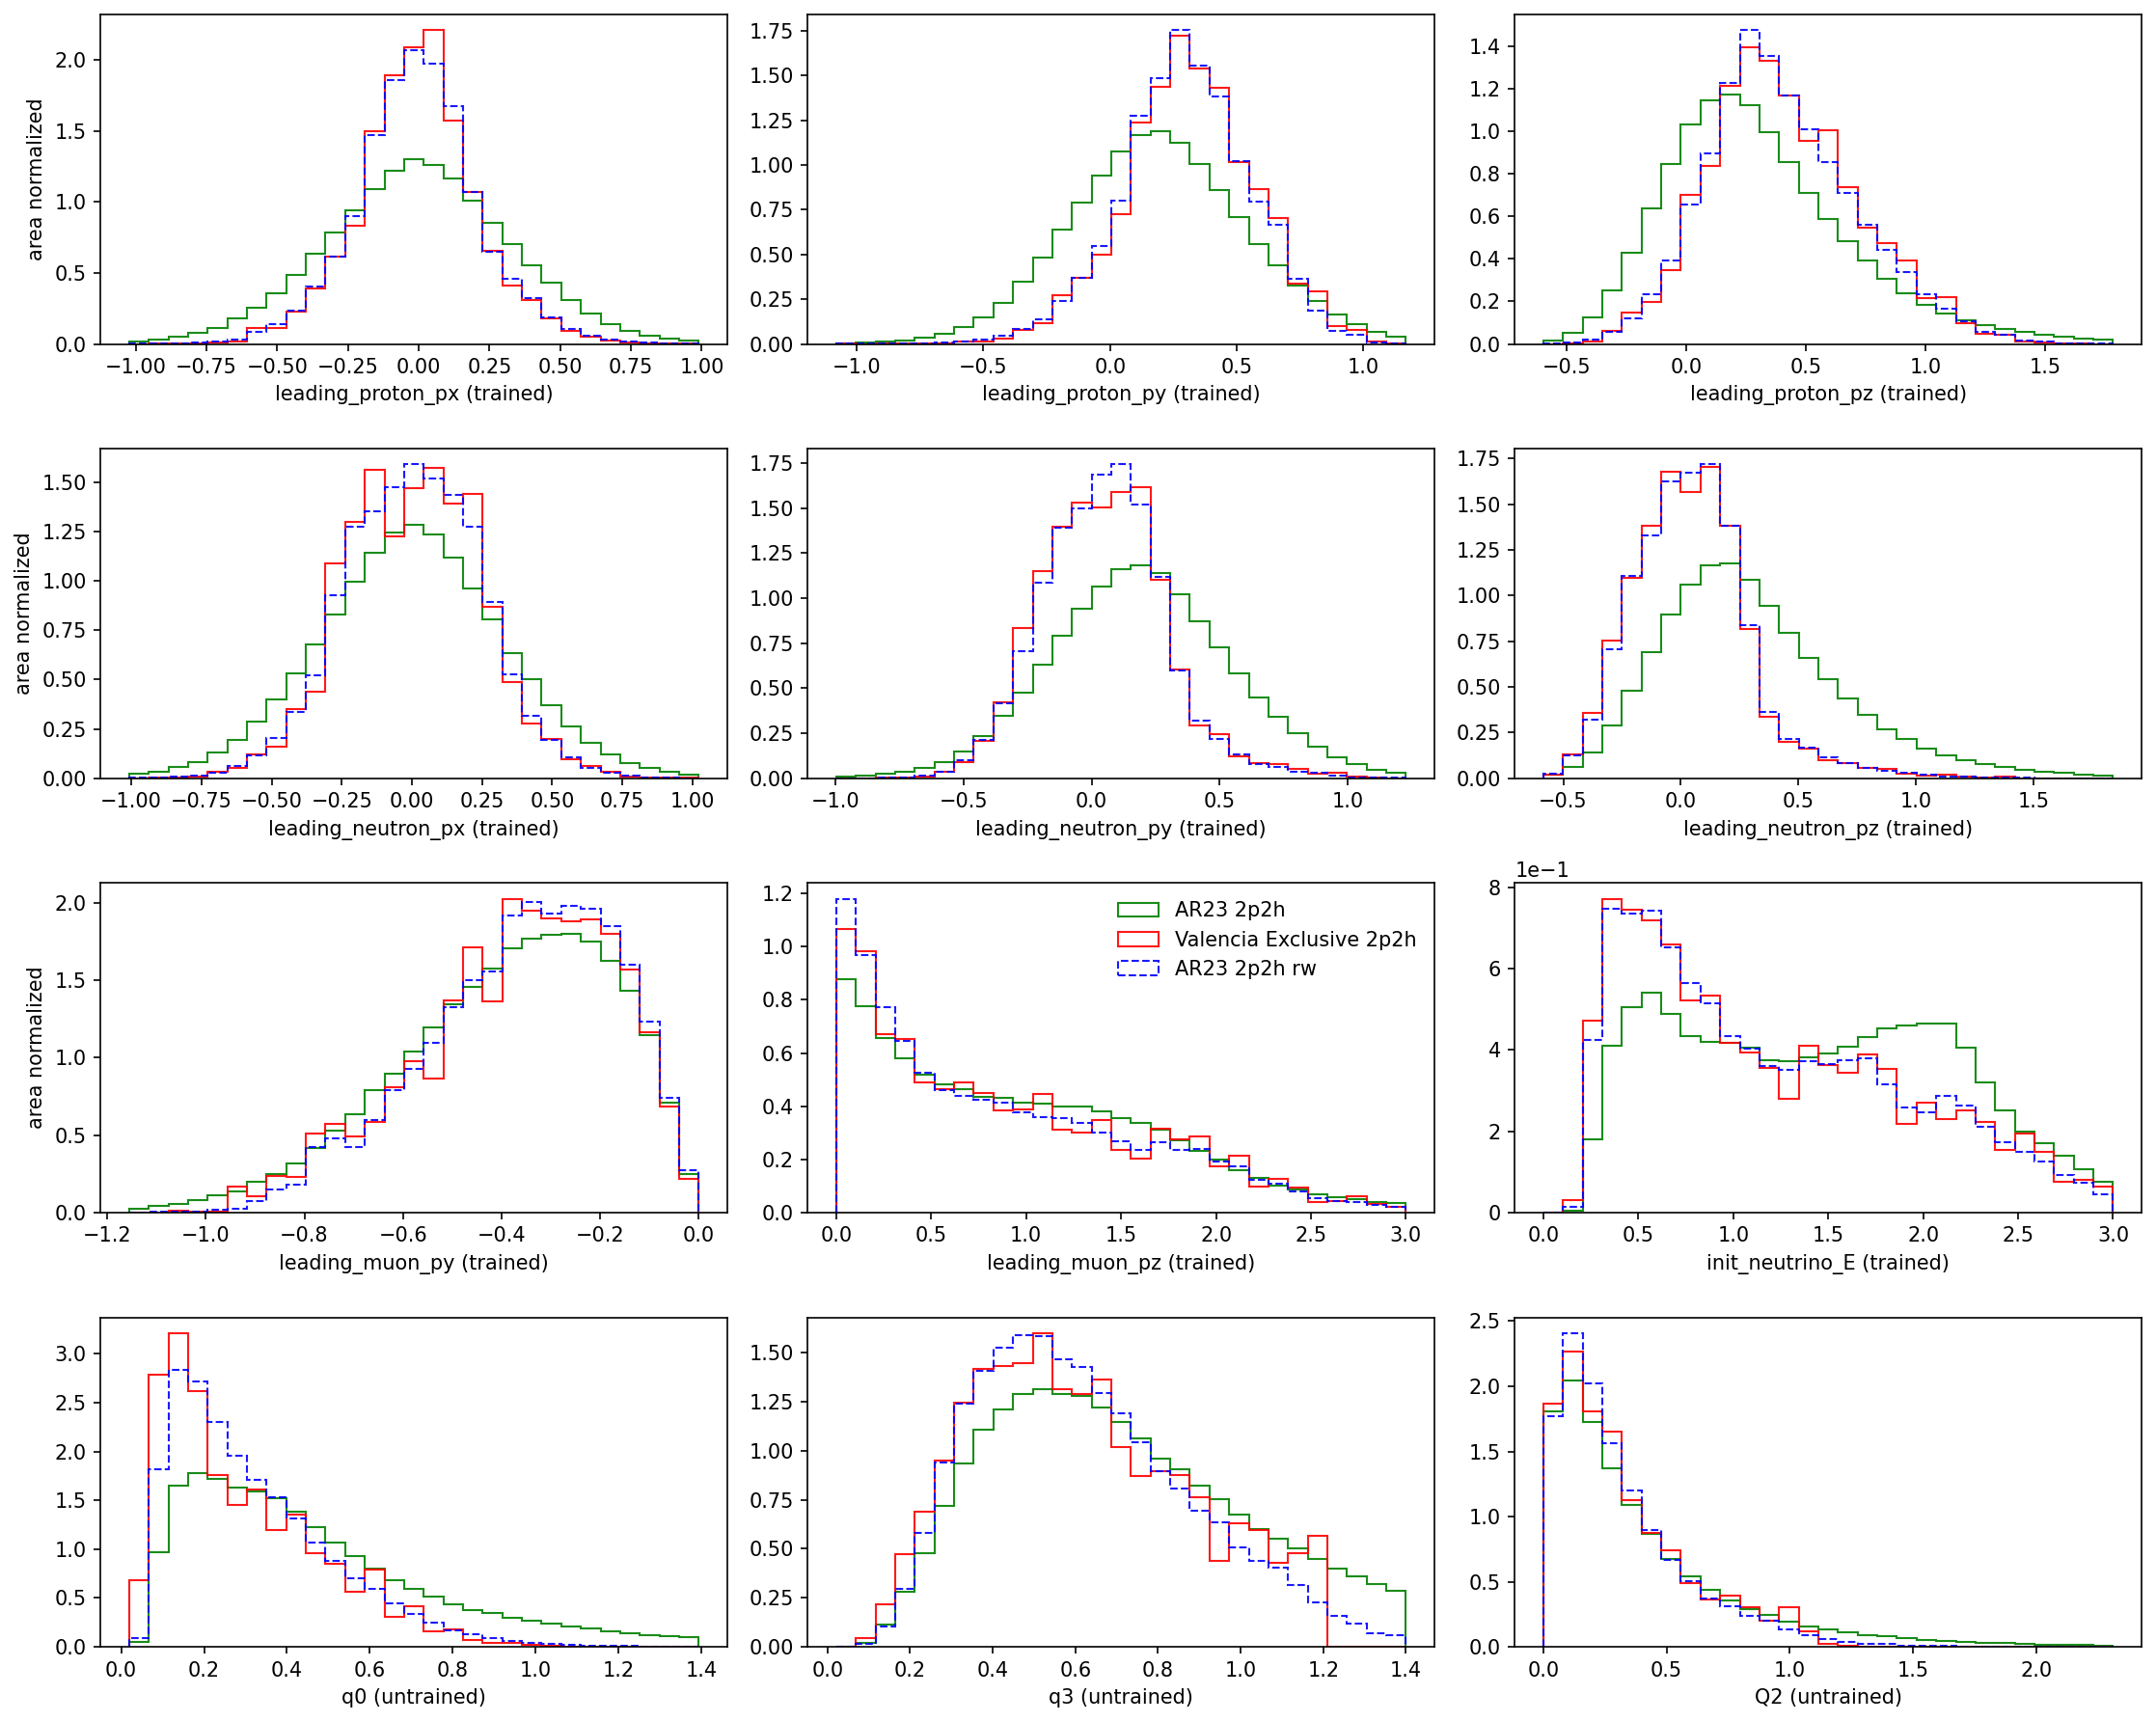

In [16]:
# plot histograms
fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
plot_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E', 'q0', 'q3', 'Q2'
]
for i, ax in enumerate(axs.flat):
    # if i == 8:
    #     continue;
    var = plot_variables[i]
    if i in [7, 8]:
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h',density=True)
    ax.hist(df_source[var], weights=df_source['weight'],     color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--',density=True)
    ax.set_xlabel(var+' (trained)' if var in reweight_variables else var+' (untrained)')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    if i == 7:
        ax.legend(frameon=False)
    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
plt.tight_layout()
plt.show()

    
    

In [17]:
# save reweighter to json
export_reweighter_json(reweighter,
    # '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_BNB_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter.json'
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter_trainWithEnu.json'

)

In [18]:
# save dataframes to csv for future use
df_source.to_csv(
    # '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_2p2h_pn_states.csv',
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_ICARUS_NuMI_2p2h_pn_states.csv',
    index=False
)

df_target.to_csv(
    '/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_ICARUS_NuMI_2p2h_pn_states.csv',
    index=False
)

